# Sección E — Transformación de datos (incisos 25 a 27)
**Responsable:** Melanie

**Propósito:** obtener una representación numérica adecuada de `Precio_Venta` (conservando la original), codificar las dimensiones categóricas para que puedan usarse en análisis posteriores y comprobar que todas las transformaciones de la Sección E dejaron tipos de dato correctos, valores dentro de rango y sin nulos ni inválidos.

**Insumo:** `data/processed/cardekho_transformado.csv` (resultado de los incisos 21 a 24, Santiago).

**¿Qué hace esta celda?** Prepara las herramientas y carga los datos.
- `numpy` se importa porque da el logaritmo (`np.log`) y el valor "vacío" `NaN`; `pandas` maneja la tabla; `matplotlib` dibuja las figuras.
- `caracteristicas` (alias `fc`) es nuestro módulo en `src/`: ahí están escritas **una sola vez** las fórmulas de esta parte, para que cualquiera del equipo las pueda reutilizar y revisar.
- `eda` es el módulo de Ricardo: se reutiliza para que todas las figuras del reporte tengan el mismo estilo y colores.
- Se guarda el tamaño inicial para comprobar al final que no se perdieron filas.

In [1]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Importación de librerías, módulos propios y carga del
#              dataset transformado (incisos 21 a 24).
# Insumo:      data/processed/cardekho_transformado.csv
# Resultado:   DataFrame df.
# ===========================================================
import sys                        # Para indicarle a Python dónde están nuestros módulos (carpeta src)
import numpy as np                # Para el logaritmo (np.log) y el valor vacío NaN
import pandas as pd               # Para manejar la tabla de datos (DataFrame)
import matplotlib.pyplot as plt   # Para dibujar las figuras
import matplotlib.ticker as mticker  # Para dar formato a los números de los ejes

# Nuestros módulos viven en la carpeta "src"; la agregamos a las rutas de búsqueda
sys.path.append("src")
import caracteristicas as fc  # Fórmulas de las Secciones E (25-26) y F
import eda                    # Estilo, colores y utilidades de gráficas (Sección A, Ricardo)

eda.configurar_estilo()                     # Mismo estilo visual en todas las figuras del reporte
pd.set_option("display.max_columns", 80)    # Mostrar todas las columnas sin "..."
pd.set_option("display.width", 200)         # Tablas anchas sin cortes de línea

RUTA_ENTRADA = "data/processed/cardekho_transformado.csv"
df = pd.read_csv(RUTA_ENTRADA, encoding="utf-8-sig")
filas_iniciales, cols_iniciales = df.shape
print(df.shape)

(15244, 36)


## E.25 Transformación de `Precio_Venta`

**¿Qué hace esta celda?** Antes de transformar algo hay que ver cómo está. Revisamos el tipo de dato y los estadísticos del precio.
**¿Qué buscamos?** Si la media está muy lejos de la mediana, unos pocos valores muy grandes la están "jalando": eso indica una distribución asimétrica.

In [2]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Diagnóstico de Precio_Venta antes de transformarla (inciso 25).
# Insumo:      df
# Resultado:   Estadísticos de Precio_Venta en INR.
# ===========================================================
precio = df["Precio_Venta"]
print("Tipo de dato:", precio.dtype)   # int64: ya es número, no hay texto que limpiar
print("Asimetría   :", round(precio.skew(), 2))  # 0 sería simétrica; > 1 ya es muy asimétrica

# describe() da conteo, media, desviación, mínimo, cuartiles y máximo;
# el lambda solo les pone separador de miles para leerlos mejor
precio.describe().apply(lambda v: f"{v:,.0f}")

Tipo de dato: int64
Asimetría   : 10.11


count        15,244
mean        774,701
std         894,676
min          40,000
25%         385,000
50%         559,000
75%         825,000
max      39,500,000
Name: Precio_Venta, dtype: str

**¿Qué hace esta celda?** Crea dos versiones nuevas del precio **sin borrar la original** (el PDF pide conservarla para comparar).
- **Lakhs:** dividimos entre 100,000 porque en India los precios se dicen en lakhs. Solo cambia la escala (como pasar de pesos a miles de pesos); la forma de los datos no cambia.
- **Logaritmo:** pasamos a escala logarítmica **ya que** "comprime" los valores grandes. Un auto 10 veces más caro solo suma +2.3 en lugar de multiplicar. Así los autos de lujo dejan de dominar la media y las gráficas.
- La tabla compara la **asimetría** (0 = simétrica) y la **curtosis** (qué tantos valores extremos hay) antes y después.

In [3]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Creación de Precio_Venta_Lakhs y Precio_Venta_Log, y
#              comparación de la forma de la distribución (inciso 25).
# Insumo:      df, módulo caracteristicas
# Resultado:   Dos dimensiones nuevas y tabla forma.
# ===========================================================
# Se conserva Precio_Venta (INR) y se agregan dos representaciones nuevas:
# - Lakhs: precio / 100,000 -> misma forma, escala más legible (4.5 en vez de 450,000)
df["Precio_Venta_Lakhs"] = fc.precio_en_lakhs(df["Precio_Venta"])
# - Log: ln(precio) -> comprime los precios altos para reducir la asimetría
df["Precio_Venta_Log"] = fc.precio_logaritmico(df["Precio_Venta"])

# Tabla comparativa: si la asimetría del log se acerca a 0, la transformación funcionó

cols_precio = ["Precio_Venta", "Precio_Venta_Lakhs", "Precio_Venta_Log"]
forma = pd.DataFrame({
    "Unidad": ["INR", "lakhs (100,000 INR)", "ln(INR)"],
    "Mínimo": df[cols_precio].min(),
    "Mediana": df[cols_precio].median(),
    "Máximo": df[cols_precio].max(),
    "Asimetría": df[cols_precio].skew(),
    "Curtosis": df[cols_precio].kurt(),
})
print(df[["Nombre"] + cols_precio].head(5), "\n")
forma.round(3)

          Nombre  Precio_Venta  Precio_Venta_Lakhs  Precio_Venta_Log
0    Maruti Alto        120000                1.20         11.695247
1  Hyundai Grand        550000                5.50         13.217674
2    Hyundai i20        215000                2.15         12.278393
3    Maruti Alto        226000                2.26         12.328290
4  Ford Ecosport        570000                5.70         13.253392 



,Unidad,Mínimo,Mediana,Máximo,Asimetría,Curtosis
Precio_Venta,INR,40000.000,559000.000,3.950000e+07,10.109,284.282
Precio_Venta_Lakhs,"lakhs (100,000 INR)",0.400,5.590,3.950000e+02,10.109,284.282
Precio_Venta_Log,ln(INR),10.597,13.234,1.749200e+01,0.564,1.472


**¿Qué hace esta celda?** Dibuja la Figura E.1 para **ver** el efecto del logaritmo. A la izquierda casi todo queda aplastado en una barra; a la derecha la forma se parece a una campana.
`formato_compacto` (de `eda`) escribe 5,000,000 como "5 M" para que el eje se lea fácil.

Guardada en: figuras\figura_E1_precio_transformado.png


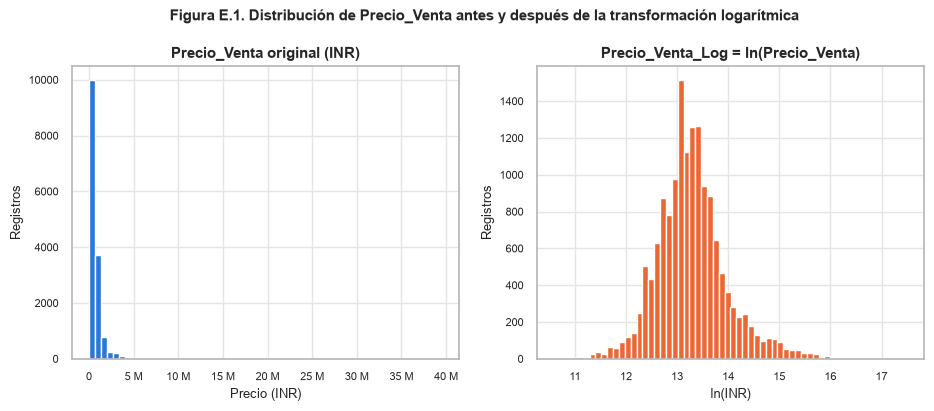

In [4]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Figura E.1: histograma de Precio_Venta original y
#              logarítmico (inciso 25).
# Insumo:      df
# Resultado:   figuras/figura_E1_precio_transformado.png
# ===========================================================
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))

ejes[0].hist(df["Precio_Venta"], bins=60, color=eda.COLOR_PRINCIPAL)
ejes[0].set_title("Precio_Venta original (INR)")
ejes[0].set_xlabel("Precio (INR)")
ejes[0].xaxis.set_major_formatter(mticker.FuncFormatter(eda.formato_compacto))

ejes[1].hist(df["Precio_Venta_Log"], bins=60, color=eda.COLOR_PRECIO)
ejes[1].set_title("Precio_Venta_Log = ln(Precio_Venta)")
ejes[1].set_xlabel("ln(INR)")

for eje in ejes:
    eje.set_ylabel("Registros")
fig.suptitle("Figura E.1. Distribución de Precio_Venta antes y después de la transformación logarítmica",
             fontsize=11, fontweight="bold", y=1.03)
print("Guardada en:", eda.guardar_figura(fig, "figura_E1_precio_transformado.png"))
plt.show()

### Justificación
Transformación de `Precio_Venta` (inciso 25): la dimensión ya era numérica (`int64`, en rupias), pero su distribución es muy asimétrica (asimetría de 10.11, curtosis de 284): la mayoría de los autos cuesta menos de 1 millón de INR y unos pocos de lujo llegan a 39.5 millones. Por eso se agregaron dos representaciones y **se conservó la original** para poder comparar resultados:

- `Precio_Venta_Lakhs` = `Precio_Venta / 100,000`. El lakh es la unidad con la que se publican los precios de autos en India; con ella 450,000 INR se lee como 4.5. Es un cambio de escala lineal, así que no cambia la forma de la distribución (misma asimetría).
- `Precio_Venta_Log` = `ln(Precio_Venta)`. El logaritmo comprime los valores grandes más que los pequeños: la asimetría baja de 10.11 a 0.56 y la curtosis de 284 a 1.47 (Figura E.1). Así los autos de lujo dejan de dominar medias, correlaciones y gráficas. Está definido para todos los registros porque el precio mínimo es 40,000 > 0. Para regresar a rupias basta con `np.exp`.

## E.26 Codificación de dimensiones categóricas

**¿Qué hace esta celda?** Lista todas las columnas de texto y cuántas clases tiene cada una.
**¿Para qué?** La técnica de codificación se elige según **cuántas clases** hay y **si tienen orden**. Esta tabla es la base de esa decisión.

In [5]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Inventario de dimensiones categóricas y su número de
#              clases para elegir la técnica de codificación (inciso 26).
# Insumo:      df
# Resultado:   Tabla clases.
# ===========================================================
categoricas = df.select_dtypes(include=["object", "string"]).columns.tolist()
clases = pd.DataFrame({
    "Clases": df[categoricas].nunique(),
    "Ejemplos": df[categoricas].apply(lambda s: ", ".join(map(str, s.unique()[:4]))),
}).sort_values("Clases")
clases

,Clases,Ejemplos
Transmisión,2,"Manual, Automatic"
Aspiracion,2,"Desconocido, std"
Ubicacion_Motor,3,"Desconocido, front, rear"
Tipo_Vendedor,3,"Individual, Dealer, Trustmark Dealer"
Traccion,3,"Desconocido, fwd, rwd"
Tipo_Motor,4,"Desconocido, ohc, dohc, ohcf"
Carroceria,4,"Desconocido, hatchback, sedan, hardtop"
Sistema_Combustible,5,"Desconocido, mpfi, idi, 1bbl"
Combustible,5,"Petrol, Diesel, CNG, LPG"
Marca,30,"Maruti, Hyundai, Ford, Renault"


**¿Qué hace esta celda?** Convierte el texto en números, porque las correlaciones y los modelos solo trabajan con números. Se usan tres técnicas:
1. **Binaria** para `Transmisión`: solo tiene 2 clases, así que con una columna 0/1 basta (1 = automática).
2. **One-hot** para las nominales con pocas clases: una columna 0/1 por clase. Se usa **en lugar de** numerarlas (0, 1, 2…) porque numerarlas inventaría un orden falso (Diesel no es "mayor" que Petrol).
3. **Frecuencia** para marca y modelo: tienen 30 y 120 clases, así que one-hot crearía 150 columnas casi vacías. Se reemplaza cada clase por la proporción de autos que la tienen.

Las columnas de texto originales **no se borran**, porque la Sección G las usa para graficar.

In [6]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Codificación de las categóricas según su naturaleza:
#              binaria, one-hot y por frecuencia (inciso 26).
# Insumo:      df, módulo caracteristicas
# Resultado:   Columnas codificadas en df y tabla resumen_cod.
# ===========================================================
# 1) Binaria: dos clases -> una sola columna 0/1 (1 = Automatic, 0 = Manual).
#    Una segunda columna "Transmision_Manual" sería redundante: siempre es lo contrario.
df["Transmision_Automatica"] = fc.codificar_binaria(df["Transmisión"], "Automatic")

# 2) One-hot: nominales con pocas clases -> una columna 0/1 por clase.
#    Ejemplo: Combustible = "Diesel" -> Combustible_Diesel = 1 y las demás = 0.
#    pd.concat pega las columnas nuevas a la derecha de df (axis=1 = por columnas).
cols_one_hot = ["Combustible", "Tipo_Vendedor", "Carroceria", "Traccion", "Aspiracion",
                "Tipo_Motor", "Ubicacion_Motor", "Sistema_Combustible"]
one_hot = fc.codificar_one_hot(df, cols_one_hot)
df = pd.concat([df, one_hot], axis=1)

# 3) Frecuencia: nominales con muchas clases -> proporción de registros de cada clase.
#    Ejemplo: maruti aparece en 4,933 de 15,244 autos -> Marca_Homologada_Frec = 0.32
cols_frecuencia = ["Marca_Homologada", "Modelo"]
for col in cols_frecuencia:
    df[col + "_Frec"] = fc.codificar_frecuencia(df[col])

resumen_cod = pd.DataFrame([
    ["Transmisión", 2, "Binaria (0/1)", "Transmision_Automatica"],
    *[[c, df[c].nunique(), "One-hot", f"{one_hot.filter(regex="^" + c + "_").shape[1]} columnas {c}_*"]
      for c in cols_one_hot],
    *[[c, df[c].nunique(), "Frecuencia", c + "_Frec"] for c in cols_frecuencia],
    ["Nombre", df["Nombre"].nunique(), "No se codifica", "(redundante con Marca + Modelo)"],
    ["Marca", df["Marca"].nunique(), "No se codifica", "(redundante con Marca_Homologada)"],
], columns=["Dimensión", "Clases", "Técnica", "Columnas generadas"])
print("Dimensiones del dataset:", (filas_iniciales, cols_iniciales), "->", df.shape)
resumen_cod

Dimensiones del dataset: (15244, 36) -> (15244, 70)


,Dimensión,Clases,Técnica,Columnas generadas
0,Transmisión,2,Binaria (0/1),Transmision_Automatica
1,Combustible,5,One-hot,5 columnas Combustible_*
2,Tipo_Vendedor,3,One-hot,3 columnas Tipo_Vendedor_*
3,Carroceria,4,One-hot,4 columnas Carroceria_*
4,Traccion,3,One-hot,3 columnas Traccion_*
5,Aspiracion,2,One-hot,2 columnas Aspiracion_*
6,Tipo_Motor,4,One-hot,4 columnas Tipo_Motor_*
7,Ubicacion_Motor,3,One-hot,3 columnas Ubicacion_Motor_*
8,Sistema_Combustible,5,One-hot,5 columnas Sistema_Combustible_*
9,Marca_Homologada,30,Frecuencia,Marca_Homologada_Frec


**¿Qué hace esta celda?** Muestra ejemplos para comprobar que cada codificación hace lo que decimos.
- La tabla cruzada confirma que todo `Automatic` quedó en 1 y todo `Manual` en 0.
- En one-hot, cada combustible tiene un 1 en **su** columna y 0 en las demás.
- En frecuencia, la columna `Comprobacion` divide los registros entre el total a mano y debe coincidir.

In [7]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Ejemplos que muestran cómo quedó cada codificación
#              (inciso 26).
# Insumo:      df
# Resultado:   Tablas de ejemplo.
# ===========================================================
print("Transmisión vs. Transmision_Automatica:")
print(pd.crosstab(df["Transmisión"], df["Transmision_Automatica"]), "\n")

print("Ejemplo one-hot de Combustible:")
print(df[["Combustible"] + [c for c in df.columns if c.startswith("Combustible_")]]
      .drop_duplicates("Combustible").to_string(index=False), "\n")

print("Ejemplo de frecuencia de Marca_Homologada:")
(df.groupby("Marca_Homologada")
   .agg(Registros=("Marca_Homologada", "size"), Marca_Homologada_Frec=("Marca_Homologada_Frec", "first"))
   .sort_values("Registros", ascending=False).head(5)
   .assign(Comprobacion=lambda t: t["Registros"] / len(df)))

Transmisión vs. Transmision_Automatica:
Transmision_Automatica      0     1
Transmisión                        
Automatic                   0  3150
Manual                  12094     0 

Ejemplo one-hot de Combustible:
Combustible  Combustible_CNG  Combustible_Diesel  Combustible_Electric  Combustible_LPG  Combustible_Petrol
     Petrol                0                   0                     0                0                   1
     Diesel                0                   1                     0                0                   0
        CNG                1                   0                     0                0                   0
        LPG                0                   0                     0                1                   0
   Electric                0                   0                     1                0                   0 

Ejemplo de frecuencia de Marca_Homologada:


,Registros,Marca_Homologada_Frec,Comprobacion
Marca_Homologada,,,
maruti,4933,0.323603,0.323603
hyundai,2952,0.193650,0.193650
honda,1476,0.096825,0.096825
mahindra,999,0.065534,0.065534
toyota,789,0.051758,0.051758


### Justificación
Codificación (inciso 26): los modelos y las correlaciones solo trabajan con números, así que cada dimensión categórica se codificó con la técnica que respeta su naturaleza. **Se conservaron las columnas de texto originales** porque la Sección G las necesita para graficar distribuciones y comparar contra el precio.

- **Binaria** para `Transmisión` (Manual / Automatic): con dos clases basta una columna, `Transmision_Automatica` (1 = automática). Dos columnas one-hot dirían lo mismo dos veces.
- **One-hot** para `Combustible`, `Tipo_Vendedor` y las categóricas de UCI (`Carroceria`, `Traccion`, `Aspiracion`, `Tipo_Motor`, `Ubicacion_Motor`, `Sistema_Combustible`): son **nominales** (no hay orden: Diesel no es "mayor" que Petrol) y tienen de 2 a 5 clases, así que generan pocas columnas. Label Encoding (0, 1, 2…) no se usó porque inventaría un orden que no existe. Se conservaron todas las clases (sin `drop_first`) para que la tabla se lea directamente y cada grupo sume 1 por fila. Dos notas:
  - `Combustible_Electric` solo tiene 4 registros, todos Toyota Camry (observación 5); su columna es casi siempre 0 y debe interpretarse con cuidado.
  - En las categóricas de UCI la clase `Desconocido` (10,760 registros de marcas sin correspondencia en UCI, imputada en la Sección D) recibe su propia columna; así el modelo distingue "sin dato de UCI" de una clase real.
- **Frecuencia** para `Marca_Homologada` (30 clases) y `Modelo` (120): one-hot agregaría 150 columnas casi vacías y Label Encoding inventaría un orden. La frecuencia resume cada clase en un solo número con significado (qué tan común es la marca o el modelo en el mercado: maruti = 0.32).
- **No se codificaron** `Nombre` y `Marca`, porque su información ya está en `Modelo` y `Marca_Homologada`.

## E.27 Comprobación de las dimensiones transformadas

**¿Qué hace esta celda?** Verifica todo lo que transformó la Sección E (inciso 27).
**¿Por qué con `assert`?** Un `assert` es una afirmación: si es falsa, el notebook **se detiene con error**. Por eso, si esta celda termina, todas las condiciones se cumplieron. No dependemos de "revisar a ojo".
Se revisan tipos, nulos, rangos, que las transformaciones del precio se puedan revertir y que cada auto tenga exactamente una clase en cada grupo one-hot.

In [8]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Comprobación de tipos, nulos y rangos de todas las
#              dimensiones transformadas en la Sección E (inciso 27).
# Insumo:      df
# Resultado:   Reporte de comprobaciones (assert).
# ===========================================================
cols_medidas = ["Millaje", "Motor", "Potencia_Máxima"]
cols_binarias = ["Transmision_Automatica"] + one_hot.columns.tolist()
cols_frec = [c + "_Frec" for c in cols_frecuencia]

# 1) Tipos de dato esperados
tipos_esperados = {**{c: "int64" for c in cols_medidas + ["Precio_Venta"] + cols_binarias},
                   "Precio_Venta_Lakhs": "float64", "Precio_Venta_Log": "float64",
                   **{c: "float64" for c in cols_frec}}
tipos_reales = df[list(tipos_esperados)].dtypes.astype(str)
tipos_ok = (tipos_reales == pd.Series(tipos_esperados)).all()
print("1) Tipos de dato correctos          :", tipos_ok)

# 2) Nulos: las transformaciones no deben generar ninguno
nulos = df[list(tipos_esperados)].isnull().sum().sum()
print("2) Nulos en dimensiones transformadas:", nulos)

# 3) Rangos válidos
rangos = {
    "Medidas 21-24 > 0": bool((df[cols_medidas] > 0).all().all()),
    "Precio_Venta_Lakhs > 0": bool((df["Precio_Venta_Lakhs"] > 0).all()),
    "Precio_Venta_Log finito": bool(np.isfinite(df["Precio_Venta_Log"]).all()),
    "Lakhs x 100,000 = Precio": bool(np.allclose(df["Precio_Venta_Lakhs"] * 100_000, df["Precio_Venta"])),
    "exp(Log) = Precio": bool(np.allclose(np.exp(df["Precio_Venta_Log"]), df["Precio_Venta"])),
    "Binarias solo 0 o 1": bool(df[cols_binarias].isin([0, 1]).all().all()),
    "Cada grupo one-hot suma 1": all((one_hot.filter(regex="^" + c + "_").sum(axis=1) == 1).all() for c in cols_one_hot),
    "Frecuencias en (0, 1]": bool(((df[cols_frec] > 0) & (df[cols_frec] <= 1)).all().all()),
}
for nombre, ok in rangos.items():
    print(f"3) {nombre:<34}:", ok)

# 4) Se conservan todas las observaciones
print("4) Observaciones antes y después    :", filas_iniciales, "->", len(df))

assert tipos_ok and nulos == 0 and all(rangos.values()) and len(df) == filas_iniciales
print("\nTodas las comprobaciones pasaron.")

1) Tipos de dato correctos          : True
2) Nulos en dimensiones transformadas: 0
3) Medidas 21-24 > 0                 : True
3) Precio_Venta_Lakhs > 0            : True
3) Precio_Venta_Log finito           : True
3) Lakhs x 100,000 = Precio          : True
3) exp(Log) = Precio                 : True
3) Binarias solo 0 o 1               : True
3) Cada grupo one-hot suma 1         : True
3) Frecuencias en (0, 1]             : True
4) Observaciones antes y después    : 15244 -> 15244

Todas las comprobaciones pasaron.


**¿Qué hace esta celda?** Muestra el mínimo, el máximo y la media de cada columna transformada, como evidencia visible de que los valores están en rangos lógicos (por ejemplo, las columnas 0/1 van de 0 a 1).

In [9]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Rango de valores de cada dimensión transformada (inciso 27).
# Insumo:      df
# Resultado:   Tabla de mínimos, máximos y medias.
# ===========================================================
df[list(tipos_esperados)].describe().T[["min", "max", "mean"]].round(3)

,min,max,mean
Millaje,4.000,3.400000e+01,19.718
Motor,793.000,6.592000e+03,1486.172
Potencia_Máxima,38.000,6.260000e+02,100.611
Precio_Venta,40000.000,3.950000e+07,774701.448
Transmision_Automatica,0.000,1.000000e+00,0.207
Combustible_CNG,0.000,1.000000e+00,0.020
Combustible_Diesel,0.000,1.000000e+00,0.482
Combustible_Electric,0.000,1.000000e+00,0.000
Combustible_LPG,0.000,1.000000e+00,0.003
Combustible_Petrol,0.000,1.000000e+00,0.496


### Justificación
Comprobación (inciso 27): se verificaron con `assert` (si algo fallara, el notebook se detendría con error) todas las dimensiones transformadas en la Sección E:
- **Tipos:** `Millaje`, `Motor` y `Potencia_Máxima` (redondeadas en el inciso 24) y las columnas binarias y one-hot son `int64`; las de precio transformado y frecuencia son `float64`.
- **Nulos:** ninguna transformación generó valores nulos.
- **Rangos:** las medidas son positivas; el precio en lakhs es positivo y el logaritmo es finito; ambas transformaciones son reversibles (× 100,000 y `exp` devuelven el precio original); las columnas codificadas solo contienen 0 y 1, cada grupo one-hot suma exactamente 1 por fila (cada auto pertenece a una sola clase) y las frecuencias están entre 0 y 1.
- **Observaciones:** se conservan los 15,244 registros; solo se agregaron columnas.

**¿Qué hace esta celda?** Guarda el resultado en un CSV nuevo, que es el punto de partida de la Sección F.
**¿Por qué un archivo nuevo?** No se sobrescribe el de Santiago: así cada etapa queda guardada y se puede revisar o volver a correr por separado. `utf-8-sig` se usa para que Excel muestre bien los acentos.

In [10]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Exportación del dataset con precio transformado y
#              categóricas codificadas, insumo de la Sección F.
# Insumo:      df
# Resultado:   data/processed/cardekho_codificado.csv
# ===========================================================
df.to_csv("data/processed/cardekho_codificado.csv", index=False, encoding="utf-8-sig")
print("Exportado:", df.shape)

Exportado: (15244, 70)
